# **🔹 Retrieval-Augmented Generation (RAG) with Unsloth Dynamic 4-Bit Quantization**

# Install Dependencies

In [ ]:
# ====== SYSTEM SETUP ======
!pip install -q unsloth
!pip install -q bitsandbytes accelerate transformers
!pip install -q sentence-transformers faiss-cpu pypdf


# Load Quantized Model

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit = True,          # Dynamic 4-bit
    dtype = None,                 # Auto (FP16 where needed)
)

FastLanguageModel.for_inference(model)

print("Model loaded with dynamic 4-bit quantization.")


# Load & Clean Documents

In [ ]:
from pypdf import PdfReader
import re

def load_documents(file_path):
    if file_path.endswith(".pdf"):
        reader = PdfReader(file_path)
        text = "\n".join([page.extract_text() for page in reader.pages])
    else:
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()

    # Basic cleaning
    text = re.sub(r"\s+", " ", text)
    return text


# Token-Aware Chunking

In [ ]:
def chunk_text(text, chunk_size=400, overlap=80):
    tokens = tokenizer.encode(text)
    chunks = []

    for i in range(0, len(tokens), chunk_size - overlap):
        chunk_tokens = tokens[i:i + chunk_size]
        chunk_text = tokenizer.decode(chunk_tokens)
        chunks.append(chunk_text)

    return chunks

# Run Ingestion

In [ ]:
doc_text = load_documents("/content/01.pdf")
chunks = chunk_text(doc_text)

print(f"Total chunks created: {len(chunks)}")

# Generate embeddings

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

embeddings = embedder.encode(
    chunks,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embeddings shape:", embeddings.shape)

# Build FAISS Index

In [ ]:
import faiss

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)

faiss.normalize_L2(embeddings)
index.add(embeddings)

print("FAISS index built.")


# Retrieval Function

In [ ]:
def retrieve(query, k=4):
    q_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)

    distances, indices = index.search(q_emb, k)
    return [chunks[i] for i in indices[0]]


# RAG Prompt Construction

In [ ]:
def build_prompt(query, retrieved_chunks):
    context = "\n\n".join(retrieved_chunks)

    prompt = f"""
SYSTEM:
You are an academic assistant.
Answer ONLY using the provided context.
If the answer is not in the context, say:
"I cannot find this information in the provided documents."

CONTEXT:
{context}

USER QUESTION:
{query}

ANSWER:
"""
    return prompt


# Inference with Quantized LLM

In [ ]:
def rag_answer(query):
    retrieved = retrieve(query)

    prompt = build_prompt(query, retrieved)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.2,
            do_sample=True
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)


# Example prompt

In [ ]:
question = "What is the main objective discussed in the document?"
print(rag_answer(question))

# Memory & VRAM Optimization Analysis

In [ ]:
torch.cuda.memory_summary(device=None, abbreviated=True)


# Architecture Diagram

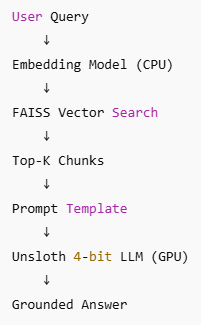